In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

img_path = '/kaggle/input/datasets/baalamurugansp/opencv-embedur/IMG_7575.jpg'
out_dir = '/kaggle/working'

***I think the Bilateral filter preserves edge details better because it computes a weighted average based on both the spatial distance and intensity similarity of neighboring pixels.***

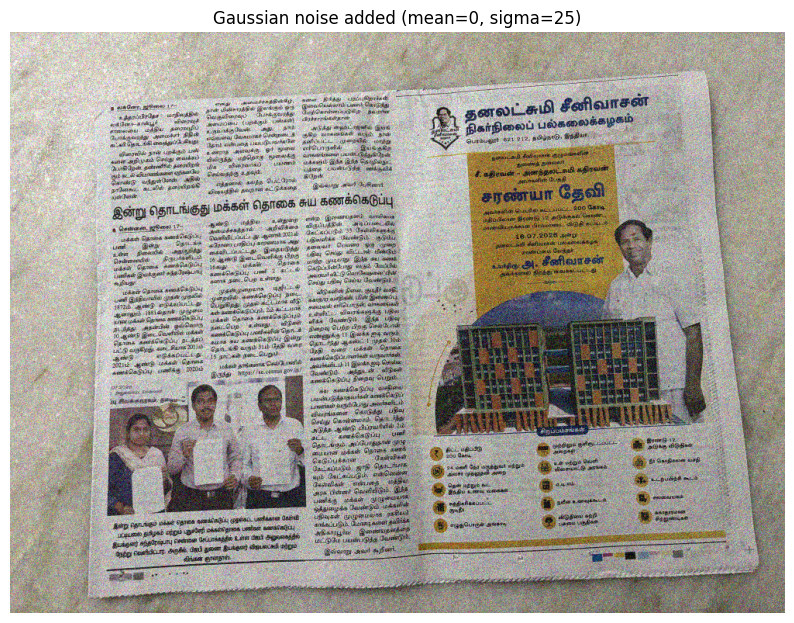

In [2]:
img = cv2.imread(img_path)
def resize_to_width(image, width=1000):
    h, w = image.shape[:2]
    s = width / w
    return cv2.resize(image, (width, int(h * s)), interpolation=cv2.INTER_AREA)

img = resize_to_width(img)

# Gaussian noise: random values drawn from a normal distribution, added
# per pixel per channel. sigma=25 controls how strong the noise is
np.random.seed(42)  # reproducible noise pattern
mean, sigma = 0, 25
gaussian_noise = np.random.normal(mean, sigma, img.shape).astype(np.float32)

# Add noise then clip back to valid pixel range, otherwise values
# below 0 or above 255 wrap around instead of saturating
noisy = img.astype(np.float32) + gaussian_noise
noisy = np.clip(noisy, 0, 255).astype(np.uint8)

cv2.imwrite(os.path.join(out_dir, 'noisy.jpg'), noisy)
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB))
plt.title(f'Gaussian noise added (mean={mean}, sigma={sigma})')
plt.axis('off')
plt.show()

In [3]:
# Mean filter: averages every pixel in the kernel equally, no edge awareness
mean_filtered = cv2.blur(noisy, (5, 5))

# Gaussian filter: weighted average, closer pixels count more, still blind to edges
gaussian_filtered = cv2.GaussianBlur(noisy, (5, 5), sigmaX=0)

# Median filter: replaces each pixel with the median of its neighborhood,
# strong at killing outlier noise spikes while keeping hard edges reasonably intact
median_filtered = cv2.medianBlur(noisy, 5)

# Bilateral filter: like Gaussian but also weighs by intensity similarity,
# so it avoids blending across strong intensity jumps (text edges)
bilateral_filtered = cv2.bilateralFilter(noisy, d=9, sigmaColor=75, sigmaSpace=75)

cv2.imwrite(os.path.join(out_dir, 'mean_filtered.jpg'), mean_filtered)
cv2.imwrite(os.path.join(out_dir, 'gaussian_filtered.jpg'), gaussian_filtered)
cv2.imwrite(os.path.join(out_dir, 'median_filtered.jpg'), median_filtered)
cv2.imwrite(os.path.join(out_dir, 'bilateral_filtered.jpg'), bilateral_filtered)

True

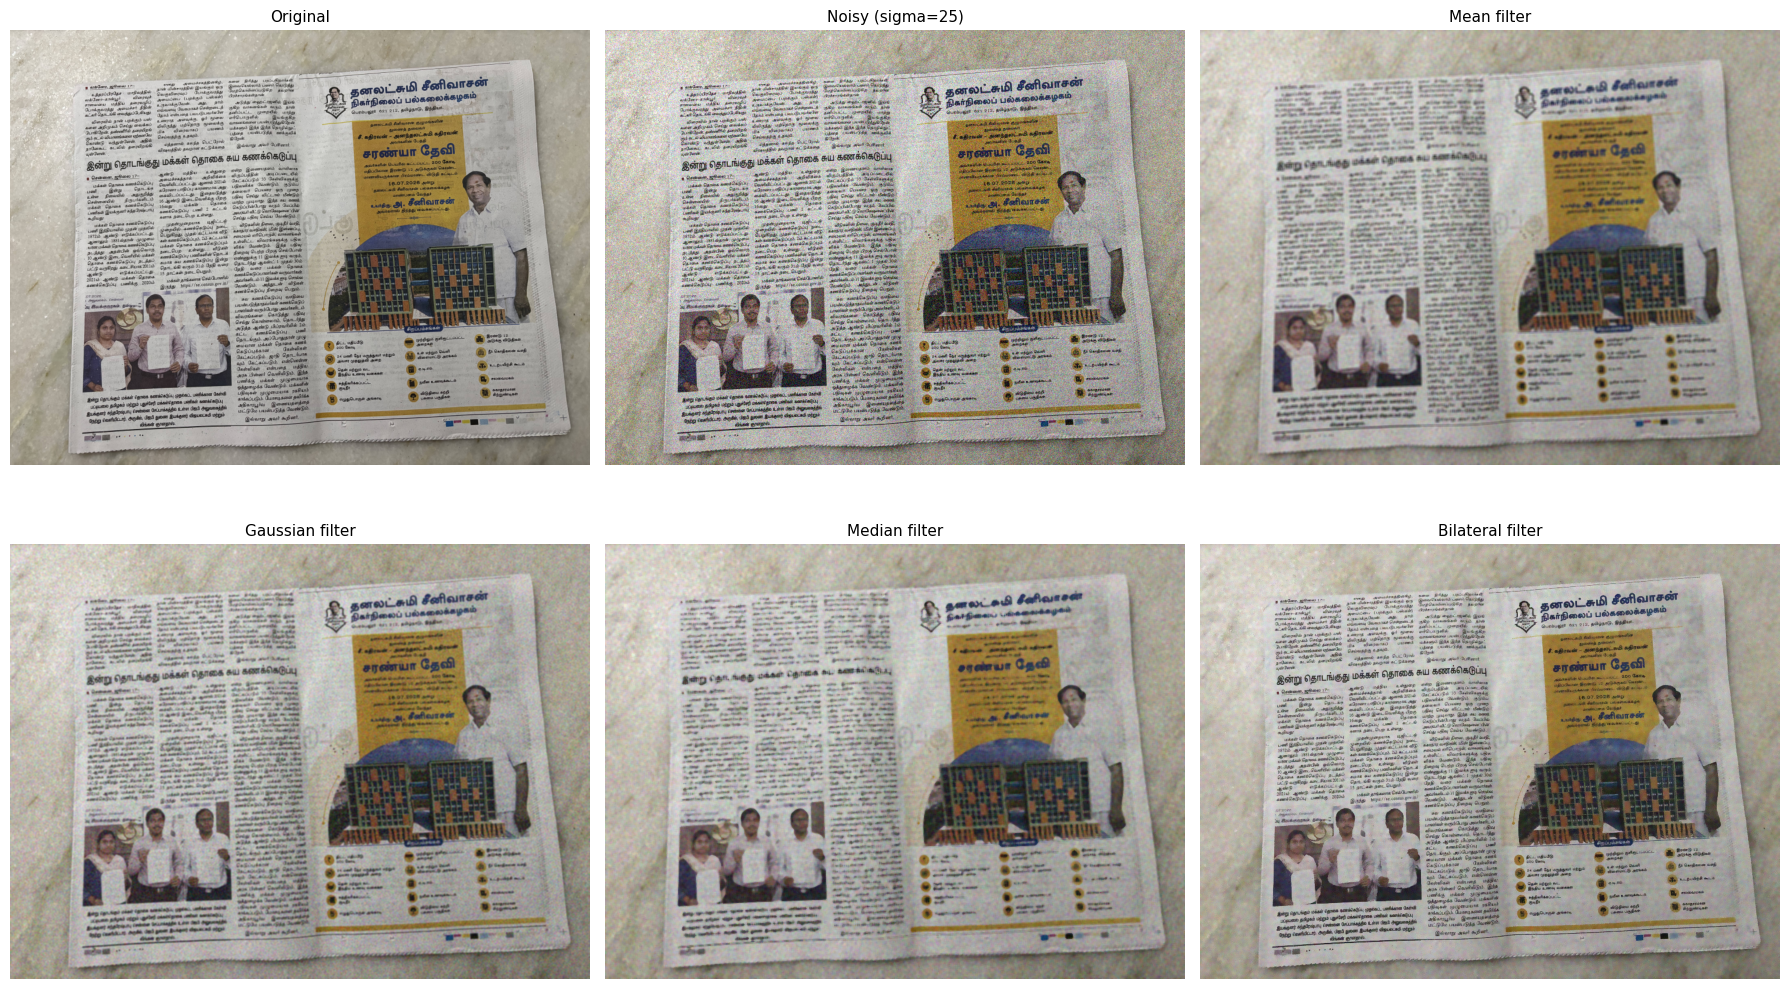

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
titles_imgs = [
    ('Original', img),
    ('Noisy (sigma=25)', noisy),
    ('Mean filter', mean_filtered),
    ('Gaussian filter', gaussian_filtered),
    ('Median filter', median_filtered),
    ('Bilateral filter', bilateral_filtered),
]
for ax, (title, im) in zip(axes.ravel(), titles_imgs):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'filters_summary.jpg'), dpi=110)
plt.show()

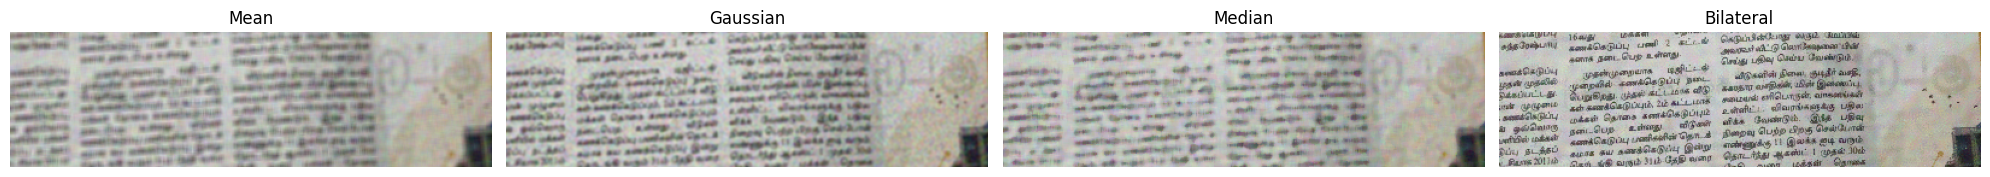

In [5]:
# A full-page view can hide edge quality differences, cropping in on
# a small text region makes stroke sharpness easier to judge by eye
h, w = img.shape[:2]
y0, y1 = int(h * 0.4), int(h * 0.55)
x0, x1 = int(w * 0.2), int(w * 0.6)

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
crops = [
    ('Mean', mean_filtered),
    ('Gaussian', gaussian_filtered),
    ('Median', median_filtered),
    ('Bilateral', bilateral_filtered),
]
for ax, (title, im) in zip(axes, crops):
    ax.imshow(cv2.cvtColor(im[y0:y1, x0:x1], cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=12)
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'filters_crop_compare.jpg'), dpi=110)
plt.show()